In [ ]:
pip install pandas numpy scikit-learn matplotlib umap-learn prince gower scikit-learn-extra kmodes optuna

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 29.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.5/179.5 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 32.3 MB/s eta 0:00:00
  Created wheel for scikit-learn-extra: filename=scikit_learn_extra-0.3.0-cp312-cp312-linux_x86_64.whl size=1959519 sha256=958ac537847497ebac141c86ca995c9bb1e310c488fba1dc141cd9907a5a71a7
  Stored in directory: /root/.cache/pip/wheels/17/4d/c3/c6d5d563c1bf8146d059d63be3678abc2f2801fba0aaf5f0b8
Successfully built scikit-learn-extra


In [ ]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# =========================
# LogPrice Regression (Train/Test)
# Target: LogPrice
# Drop leakage: Price
# Models (small, well-known set):
#   Linear: LinearRegression, Ridge, Lasso, ElasticNet
#   Bagging: RandomForest
#   Boosting: HistGradientBoosting, XGBoost, CatBoost
# Metrics reported for BOTH train & test:
#   R2, MSE, MAPE(%)
# =========================

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

# ---------- OPTIONAL (external boosters) ----------
# Install if needed:
# pip install xgboost catboost
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False

try:
    from catboost import CatBoostRegressor
    HAS_CAT = True
except Exception:
    HAS_CAT = False


# ---------- CONFIG ----------
TRAIN_PATH = "/content/drive/MyDrive/Diamond Dataset/Datasets/Train Dataset with Log Price.csv"   # <-- change to your train CSV filename
TEST_PATH  = "/content/drive/MyDrive/Diamond Dataset/Datasets/Test Dataset with Log Price.csv"    # <-- change to your test CSV filename
TARGET_COL = "LogPrice"
DROP_PREDICTORS = ["Price", "LogPrice"]  # remove from X (LogPrice is target; Price is leakage)


# ---------- METRICS ----------
def mape(y_true, y_pred, eps=1e-8):
    """
    MAPE on LogPrice (as requested).
    Note: MAPE on logs is mathematically unusual but OK if that's what your rubric expects.
    If your professor wants MAPE on original price scale, ask and I’ll adapt.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.clip(np.abs(y_true), eps, None)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100.0)


def evaluate_model(name, pipe, X_train, y_train, X_test, y_test):
    pipe.fit(X_train, y_train)

    pred_tr = pipe.predict(X_train)
    pred_te = pipe.predict(X_test)

    out = {
        "Model": name,
        "Train_R2": float(r2_score(y_train, pred_tr)),
        "Test_R2": float(r2_score(y_test, pred_te)),
        "Train_MSE": float(mean_squared_error(y_train, pred_tr)),
        "Test_MSE": float(mean_squared_error(y_test, pred_te)),
        "Train_MAPE(%)": float(mape(y_train, pred_tr)),
        "Test_MAPE(%)": float(mape(y_test, pred_te)),
    }
    return out


# ---------- LOAD DATA ----------
train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

assert TARGET_COL in train_df.columns, f"{TARGET_COL} not found in train CSV"
assert TARGET_COL in test_df.columns,  f"{TARGET_COL} not found in test CSV"

y_train = train_df[TARGET_COL]
y_test  = test_df[TARGET_COL]

X_train = train_df.drop(columns=[c for c in DROP_PREDICTORS if c in train_df.columns])
X_test  = test_df.drop(columns=[c for c in DROP_PREDICTORS if c in test_df.columns])

# Column types
cat_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = [c for c in X_train.columns if c not in cat_cols]

# ---------- PREPROCESS ----------
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop"
)

# ---------- DEFINE MODELS (small, well-known) ----------
models = {
    # Linear family
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "Lasso": Lasso(alpha=0.001, random_state=42, max_iter=10000),
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.2, random_state=42, max_iter=10000),

    # Bagging
    "RandomForest": RandomForestRegressor(
        n_estimators=400,
        random_state=42,
        n_jobs=-1
    ),

    # Boosting (sklearn)
    "HistGradientBoosting": HistGradientBoostingRegressor(
        random_state=42
    ),
}

# Boosting (XGBoost)
if HAS_XGB:
    models["XGBoost"] = XGBRegressor(
        n_estimators=800,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
else:
    print("NOTE: xgboost not installed. Run: pip install xgboost  (XGBoost model will be skipped)")

# Boosting (CatBoost) - handles categorical well, but we keep same preprocessing for consistency
if HAS_CAT:
    models["CatBoost"] = CatBoostRegressor(
        iterations=2000,
        learning_rate=0.05,
        depth=8,
        loss_function="RMSE",
        random_seed=42,
        verbose=0
    )
else:
    print("NOTE: catboost not installed. Run: pip install catboost  (CatBoost model will be skipped)")


# ---------- RUN TRAIN/TEST EVALUATION ----------
rows = []
for name, model in models.items():
    pipe = Pipeline(steps=[("prep", preprocess), ("model", model)])
    rows.append(evaluate_model(name, pipe, X_train, y_train, X_test, y_test))

results_df = pd.DataFrame(rows).sort_values("Test_MSE")
print("\n===== Model Performance (sorted by Test_MSE) =====")
print(results_df.to_string(index=False))

best = results_df.iloc[0]
print("\n===== Best Model (by Test_MSE) =====")
for k, v in best.items():
    print(f"{k}: {v}")


===== Model Performance (sorted by Test_MSE) =====
               Model  Train_R2  Test_R2  Train_MSE  Test_MSE  Train_MAPE(%)  Test_MAPE(%)
            CatBoost  0.999104 0.998882   0.004994  0.006182       0.998067      1.102665
             XGBoost  0.999049 0.998835   0.005300  0.006444       1.030571      1.144645
        RandomForest  0.999783 0.998515   0.001208  0.008212       0.488573      1.296243
HistGradientBoosting  0.998422 0.998395   0.008793  0.008875       1.396531      1.423879
               Ridge  0.996588 0.996651   0.019014  0.018518       2.109776      2.102266
    LinearRegression  0.996588 0.996651   0.019014  0.018518       2.109750      2.102241
          ElasticNet  0.996548 0.996624   0.019234  0.018671       2.121337      2.113961
               Lasso  0.996507 0.996566   0.019465  0.018989       2.131287      2.125186

===== Best Model (by Test_MSE) =====
Model: CatBoost
Train_R2: 0.9991038117072588
Test_R2: 0.9988820481534401
Train_MSE: 0.00499379678309

In [ ]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from scipy.stats import uniform, loguniform, randint

# --- Definitions copied from vrlIcR_fErSn ---
RANDOM_STATE = 42
VAL_SIZE = 0.2

def mape_log(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.clip(np.abs(y_true), eps, None)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100.0)

def evaluate(y_true, y_pred):
    return {
        "R2": float(r2_score(y_true, y_pred)),
        "MSE": float(mean_squared_error(y_true, y_pred)),
        "MAPE(%)": float(mape_log(y_true, y_pred)),
    }

def evaluate_model_on_train_test(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    pred_tr = model.predict(X_train)
    pred_te = model.predict(X_test)

    tr = evaluate(y_train, pred_tr)
    te = evaluate(y_test, pred_te)

    return {
        "Train_R2": tr["R2"], "Train_MSE": tr["MSE"], "Train_MAPE(%)": tr["MAPE(%)"],
        "Test_R2":  te["R2"], "Test_MSE":  te["MSE"], "Test_MAPE(%)":  te["MAPE(%)"],
    }
# --- End copied definitions ---


# --- Data Loading and Preprocessing from vrlIcR_fErSn ---
TRAIN_PATH = "/content/drive/MyDrive/Diamond Dataset/Datasets/Train Dataset with Log Price.csv"
TEST_PATH  = "/content/drive/MyDrive/Diamond Dataset/Datasets/Test Dataset with Log Price.csv"
TARGET_COL = "LogPrice"
DROP_PREDICTORS = ["Price", "LogPrice"]

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

y_train_full = train_df[TARGET_COL]
y_test = test_df[TARGET_COL]

X_train_full = train_df.drop(columns=[c for c in DROP_PREDICTORS if c in train_df.columns])
X_test = test_df.drop(columns=[c for c in DROP_PREDICTORS if c in test_df.columns])

cat_cols = X_train_full.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = [c for c in X_train_full.columns if c not in cat_cols]

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols),
], remainder="drop")

X_fit, X_val, y_fit, y_val = train_test_split(
    X_train_full, y_train_full, test_size=VAL_SIZE, random_state=RANDOM_STATE
)

preprocess_fit = preprocess.fit(X_fit)
X_fit_t = preprocess_fit.transform(X_fit)
X_val_t = preprocess_fit.transform(X_val)

preprocess_full = preprocess.fit(X_train_full)
X_train_t = preprocess_full.transform(X_train_full)
X_test_t  = preprocess_full.transform(X_test)
# --- End Data Loading and Preprocessing ---


print("Starting tuning for Linear, Ridge, Lasso, ElasticNet, and RandomForest.")

tuned_results_additional = {}
best_params_additional = {}

# --- LinearRegression (No hyperparameters to tune for basic version) ---
print("\n=== Evaluating LinearRegression ===")
lr_model = LinearRegression()
lr_metrics = evaluate_model_on_train_test(
    lr_model, X_train_t, y_train_full, X_test_t, y_test
)
tuned_results_additional["LinearRegression"] = lr_metrics
best_params_additional["LinearRegression"] = {} # No tunable params

# --- RandomizedSearchCV for Ridge, Lasso, ElasticNet, RandomForestRegressor ---

N_ITER_SEARCH = 40 # Number of parameter settings that are sampled. Trades off execution time with quality of solution.

# Ridge Regression Tuning
print("\n=== Randomized Search Tuning: Ridge ===")
param_dist_ridge = {"alpha": loguniform(1e-3, 10.0)}
ridge_rs = RandomizedSearchCV(Ridge(random_state=RANDOM_STATE), param_dist_ridge,
                              n_iter=N_ITER_SEARCH, cv=5, scoring="neg_mean_squared_error",
                              random_state=RANDOM_STATE, n_jobs=-1, verbose=1)
ridge_rs.fit(X_fit_t, y_fit)
best_ridge_params = ridge_rs.best_params_
best_params_additional["Ridge"] = best_ridge_params
print("Best Ridge params:", best_ridge_params)

tuned_ridge = Ridge(**best_ridge_params, random_state=RANDOM_STATE)
tuned_results_additional["Ridge"] = evaluate_model_on_train_test(
    tuned_ridge, X_train_t, y_train_full, X_test_t, y_test
)

# Lasso Regression Tuning
print("\n=== Randomized Search Tuning: Lasso ===")
param_dist_lasso = {"alpha": loguniform(1e-4, 1.0)}
lasso_rs = RandomizedSearchCV(Lasso(random_state=RANDOM_STATE, max_iter=10000), param_dist_lasso,
                              n_iter=N_ITER_SEARCH, cv=5, scoring="neg_mean_squared_error",
                              random_state=RANDOM_STATE, n_jobs=-1, verbose=1)
lasso_rs.fit(X_fit_t, y_fit)
best_lasso_params = lasso_rs.best_params_
best_params_additional["Lasso"] = best_lasso_params
print("Best Lasso params:", best_lasso_params)

tuned_lasso = Lasso(**best_lasso_params, random_state=RANDOM_STATE, max_iter=10000)
tuned_results_additional["Lasso"] = evaluate_model_on_train_test(
    tuned_lasso, X_train_t, y_train_full, X_test_t, y_test
)

# ElasticNet Tuning
print("\n=== Randomized Search Tuning: ElasticNet ===")
param_dist_elasticnet = {
    "alpha": loguniform(1e-4, 1.0),
    "l1_ratio": uniform(0.0, 1.0)
}
elasticnet_rs = RandomizedSearchCV(ElasticNet(random_state=RANDOM_STATE, max_iter=10000), param_dist_elasticnet,
                                   n_iter=N_ITER_SEARCH, cv=5, scoring="neg_mean_squared_error",
                                   random_state=RANDOM_STATE, n_jobs=-1, verbose=1)
elasticnet_rs.fit(X_fit_t, y_fit)
best_elasticnet_params = elasticnet_rs.best_params_
best_params_additional["ElasticNet"] = best_elasticnet_params
print("Best ElasticNet params:", best_elasticnet_params)

tuned_elasticnet = ElasticNet(**best_elasticnet_params, random_state=RANDOM_STATE, max_iter=10000)
tuned_results_additional["ElasticNet"] = evaluate_model_on_train_test(
    tuned_elasticnet, X_train_t, y_train_full, X_test_t, y_test
)

# RandomForestRegressor Tuning
print("\n=== Randomized Search Tuning: RandomForestRegressor ===")
param_dist_rf = {
    "n_estimators": randint(100, 1000),
    "max_depth": randint(5, 20),
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 10),
    "max_features": ["sqrt", "log2", 0.5, 0.7, 0.9, 1.0]
}
rf_rs = RandomizedSearchCV(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1), param_dist_rf,
                           n_iter=N_ITER_SEARCH, cv=5, scoring="neg_mean_squared_error",
                           random_state=RANDOM_STATE, n_jobs=-1, verbose=1)
rf_rs.fit(X_fit_t, y_fit)
best_rf_params = rf_rs.best_params_
best_params_additional["RandomForest"] = best_rf_params
print("Best RandomForest params:", best_rf_params)

tuned_rf = RandomForestRegressor(**best_rf_params, random_state=RANDOM_STATE, n_jobs=-1)
tuned_results_additional["RandomForest"] = evaluate_model_on_train_test(
    tuned_rf, X_train_t, y_train_full, X_test_t, y_test
)

# --- Combine results with previously tuned models (CatBoost, XGBoost, HistGradientBoosting) ---
# Assuming 'tuned_results' and 'best_params' from cell vrlIcR_fErSn are available
# If not, the user would need to re-run vrlIcR_fErSn first.
# For now, I'll assume they are and combine.

# Create dummy placeholders if not available for execution in isolation
# In an interactive session, these would persist from previous cell execution
if 'tuned_results' not in globals():
    tuned_results = {}
if 'best_params' not in globals():
    best_params = {}

# Merge the new results with existing ones
tuned_results.update(tuned_results_additional)
best_params.update(best_params_additional)


# ======================
# FINAL COMPARISON TABLE
# ======================
rows = []
for model_name in tuned_results.keys():
    rows.append({
        "Model": model_name,
        "Version": "Tuned (Randomized Search)", # Update version description
        **tuned_results[model_name]
    })

compare_df_all_tuned = pd.DataFrame(rows).sort_values("Test_MSE").reset_index(drop=True)

print("\n===== ALL Tuned Model Performance (sorted by Test_MSE) ====")
print(compare_df_all_tuned.to_string(index=False))

print("\n===== Best Parameters for All Tuned Models ====")
for k, v in best_params.items():
    print(f"\n{k}:")
    for pk, pv in v.items():
        print(f"  {pk}: {pv}")

Starting tuning for Linear, Ridge, Lasso, ElasticNet, and RandomForest.

=== Evaluating LinearRegression ===

=== Randomized Search Tuning: Ridge ===
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Ridge params: {'alpha': np.float64(0.0012087541473056963)}

=== Randomized Search Tuning: Lasso ===
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Lasso params: {'alpha': np.float64(0.0004207053950287938)}

=== Randomized Search Tuning: ElasticNet ===
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best ElasticNet params: {'alpha': np.float64(0.00019870215385428647), 'l1_ratio': np.float64(0.9868869366005173)}

=== Randomized Search Tuning: RandomForestRegressor ===
Fitting 5 folds for each of 40 candidates, totalling 200 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.ensemble import HistGradientBoostingRegressor

# pip install xgboost catboost tqdm
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from tqdm.auto import tqdm


# ======================
# CONFIG
# ======================
TARGET_COL = "LogPrice"
DROP_PREDICTORS = ["Price", "LogPrice"]  # remove from X

RANDOM_STATE = 42
TUNING_ITERS = 25          # small search; increase to 50 if you want
VAL_SIZE = 0.2             # split from TRAIN for tuning/early-stopping


# ======================
# METRICS
# ======================
def mape_log(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.clip(np.abs(y_true), eps, None)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100.0)

def eval_metrics(y_true, y_pred):
    return {
        "R2": float(r2_score(y_true, y_pred)),
        "MSE": float(mean_squared_error(y_true, y_pred)),
        "MAPE(%)": float(mape_log(y_true, y_pred)),
    }

def evaluate_pipeline(pipe, X_train, y_train, X_test, y_test):
    pipe.fit(X_train, y_train)
    pred_tr = pipe.predict(X_train)
    pred_te = pipe.predict(X_test)

    tr = eval_metrics(y_train, pred_tr)
    te = eval_metrics(y_test, pred_te)

    return {
        "Train_R2": tr["R2"], "Train_MSE": tr["MSE"], "Train_MAPE(%)": tr["MAPE(%)"],
        "Test_R2":  te["R2"], "Test_MSE":  te["MSE"], "Test_MAPE(%)":  te["MAPE(%)"],
    }


# ======================
# LOAD DATA
# ======================
train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

assert TARGET_COL in train_df.columns, f"{TARGET_COL} not found in train CSV"
assert TARGET_COL in test_df.columns,  f"{TARGET_COL} not found in test CSV"

y_train_full = train_df[TARGET_COL]
y_test = test_df[TARGET_COL]

X_train_full = train_df.drop(columns=[c for c in DROP_PREDICTORS if c in train_df.columns])
X_test = test_df.drop(columns=[c for c in DROP_PREDICTORS if c in test_df.columns])

# Identify types
cat_cols = X_train_full.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = [c for c in X_train_full.columns if c not in cat_cols]

# Preprocess (same as your previous pipeline)
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop"
)

# Split TRAIN into fit/validation for tuning (keep TEST untouched)
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train_full, y_train_full, test_size=VAL_SIZE, random_state=RANDOM_STATE
)


# ======================
# BASELINES (your current-ish settings)
# ======================
baseline_models = {
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=RANDOM_STATE),
    "XGBoost": XGBRegressor(
        n_estimators=800, learning_rate=0.05, max_depth=6,
        subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
        objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=-1
    ),
    "CatBoost": CatBoostRegressor(
        iterations=2000, learning_rate=0.05, depth=8,
        loss_function="RMSE", random_seed=RANDOM_STATE, verbose=0
    ),
}

baseline_results = {}
for name, model in baseline_models.items():
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    baseline_results[name] = evaluate_pipeline(pipe, X_train_full, y_train_full, X_test, y_test)


# ======================
# TUNING HELPERS (small randomized search with progress bar)
# ======================
def sample_params(rng, space):
    # space: dict[str, list|tuple|callable]
    params = {}
    for k, v in space.items():
        if callable(v):
            params[k] = v(rng)
        else:
            params[k] = v[rng.randint(0, len(v))]
    return params

def tune_model(model_name, base_model, param_space, n_iter=25):
    rng = np.random.RandomState(RANDOM_STATE)
    best = {"val_mse": np.inf, "params": None, "pipe": None}

    pbar = tqdm(range(n_iter), desc=f"Tuning {model_name}", leave=True)
    for _ in pbar:
        params = sample_params(rng, param_space)

        # fresh model with params
        model = base_model(**params)

        pipe = Pipeline([("prep", preprocess), ("model", model)])

        # Fit on X_fit, validate on X_val (fast + keeps TEST untouched)
        pipe.fit(X_fit, y_fit)
        pred_val = pipe.predict(X_val)
        val_mse = mean_squared_error(y_val, pred_val)

        if val_mse < best["val_mse"]:
            best = {"val_mse": val_mse, "params": params, "pipe": pipe}

        pbar.set_postfix(best_val_mse=f"{best['val_mse']:.6f}")

    # Refit best pipe on FULL TRAIN and return final test metrics
    best_pipe = Pipeline([("prep", preprocess), ("model", base_model(**best["params"]))])
    best_pipe.fit(X_train_full, y_train_full)

    tuned_metrics = evaluate_pipeline(best_pipe, X_train_full, y_train_full, X_test, y_test)
    return best["params"], best["val_mse"], tuned_metrics


# ======================
# PARAMETER SPACES (compact but effective)
# ======================

# 1) HistGradientBoosting (sklearn)
hgb_space = {
    "learning_rate": [0.03, 0.05, 0.07, 0.1],
    "max_depth": [None, 4, 6, 8],
    "max_leaf_nodes": [15, 31, 63, 127],
    "min_samples_leaf": [10, 20, 30, 50],
    "l2_regularization": [0.0, 0.1, 1.0, 5.0],
    "max_bins": [128, 255],
    "random_state": [RANDOM_STATE],
}

# 2) XGBoost
xgb_space = {
    "n_estimators": [600, 900, 1200, 1600],
    "learning_rate": [0.02, 0.03, 0.05, 0.08],
    "max_depth": [4, 5, 6, 7, 8],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 8],
    "reg_lambda": [0.5, 1.0, 2.0, 5.0],
    "gamma": [0.0, 0.1, 0.2],
    "objective": ["reg:squarederror"],
    "random_state": [RANDOM_STATE],
    "n_jobs": [-1],
}

# 3) CatBoost
cat_space = {
    "iterations": [1200, 1600, 2000, 2500],
    "learning_rate": [0.02, 0.03, 0.05, 0.08],
    "depth": [6, 7, 8, 9, 10],
    "l2_leaf_reg": [1, 3, 5, 7, 10],
    "random_strength": [0.0, 0.5, 1.0, 2.0],
    "bagging_temperature": [0.0, 0.5, 1.0, 2.0],
    "loss_function": ["RMSE"],
    "random_seed": [RANDOM_STATE],
    "verbose": [0],
}


# ======================
# RUN TUNING
# ======================
tuned_results = {}
best_params = {}

# HistGradientBoosting
bp, val_mse, metrics = tune_model(
    "HistGradientBoosting",
    base_model=lambda **kw: HistGradientBoostingRegressor(**kw),
    param_space=hgb_space,
    n_iter=TUNING_ITERS
)
best_params["HistGradientBoosting"] = bp
tuned_results["HistGradientBoosting"] = metrics

# XGBoost
bp, val_mse, metrics = tune_model(
    "XGBoost",
    base_model=lambda **kw: XGBRegressor(**kw),
    param_space=xgb_space,
    n_iter=TUNING_ITERS
)
best_params["XGBoost"] = bp
tuned_results["XGBoost"] = metrics

# CatBoost
bp, val_mse, metrics = tune_model(
    "CatBoost",
    base_model=lambda **kw: CatBoostRegressor(**kw),
    param_space=cat_space,
    n_iter=TUNING_ITERS
)
best_params["CatBoost"] = bp
tuned_results["CatBoost"] = metrics


# ======================
# COMPARE: BASELINE vs TUNED
# ======================
rows = []
for name in ["CatBoost", "XGBoost", "HistGradientBoosting"]:
    base = baseline_results[name]
    tuned = tuned_results[name]

    rows.append({
        "Model": name,
        "Version": "Baseline",
        **base
    })
    rows.append({
        "Model": name,
        "Version": "Tuned",
        **tuned
    })

compare_df = pd.DataFrame(rows)
# Sort by Test_MSE (best on top)
compare_df = compare_df.sort_values(["Test_MSE", "Model", "Version"]).reset_index(drop=True)

print("\n===== Baseline vs Tuned Comparison (sorted by Test_MSE) =====")
print(compare_df.to_string(index=False))

print("\n===== Best Parameters Found =====")
for k, v in best_params.items():
    print(f"\n{k}:")
    for pk, pv in v.items():
        print(f"  {pk}: {pv}")

Tuning HistGradientBoosting:   0%|          | 0/25 [00:00<?, ?it/s]

Tuning XGBoost:   0%|          | 0/25 [00:00<?, ?it/s]

Tuning CatBoost:   0%|          | 0/25 [00:00<?, ?it/s]


===== Baseline vs Tuned Comparison (sorted by Test_MSE) =====
               Model  Version  Train_R2  Train_MSE  Train_MAPE(%)  Test_R2  Test_MSE  Test_MAPE(%)
             XGBoost    Tuned  0.999612   0.002160       0.631571 0.999066  0.005164      0.984758
            CatBoost    Tuned  0.999387   0.003414       0.814332 0.998993  0.005567      1.033080
            CatBoost Baseline  0.999104   0.004994       0.998067 0.998882  0.006182      1.102665
             XGBoost Baseline  0.999049   0.005300       1.030571 0.998835  0.006444      1.144645
HistGradientBoosting    Tuned  0.998823   0.006556       1.157901 0.998648  0.007475      1.248487
HistGradientBoosting Baseline  0.998422   0.008793       1.396531 0.998395  0.008875      1.423879

===== Best Parameters Found =====

HistGradientBoosting:
  learning_rate: 0.1
  max_depth: None
  max_leaf_nodes: 127
  min_samples_leaf: 20
  l2_regularization: 0.1
  max_bins: 255
  random_state: 42

XGBoost:
  n_estimators: 1200
  learning_

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.ensemble import HistGradientBoostingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

import optuna


# ======================
# CONFIG
# ======================
TARGET_COL = "LogPrice"
DROP_PREDICTORS = ["Price", "LogPrice"]   # drop leakage + target from X

RANDOM_STATE = 42
VAL_SIZE = 0.2

# Bayesian tuning trials (increase if you want)
N_TRIALS_HGB = 40
N_TRIALS_XGB = 40
N_TRIALS_CAT = 40

EARLY_STOPPING_ROUNDS = 50


# ======================
# METRICS
# ======================
def mape_log(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.clip(np.abs(y_true), eps, None)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100.0)

def evaluate(y_true, y_pred):
    return {
        "R2": float(r2_score(y_true, y_pred)),
        "MSE": float(mean_squared_error(y_true, y_pred)),
        "MAPE(%)": float(mape_log(y_true, y_pred)),
    }

def evaluate_model_on_train_test(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    pred_tr = model.predict(X_train)
    pred_te = model.predict(X_test)

    tr = evaluate(y_train, pred_tr)
    te = evaluate(y_test, pred_te)

    return {
        "Train_R2": tr["R2"], "Train_MSE": tr["MSE"], "Train_MAPE(%)": tr["MAPE(%)"],
        "Test_R2":  te["R2"], "Test_MSE":  te["MSE"], "Test_MAPE(%)":  te["MAPE(%)"],
    }


# ======================
# LOAD DATA
# ======================
train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

assert TARGET_COL in train_df.columns, f"{TARGET_COL} not found in train CSV"
assert TARGET_COL in test_df.columns,  f"{TARGET_COL} not found in test CSV"

y_train_full = train_df[TARGET_COL]
y_test = test_df[TARGET_COL]

X_train_full = train_df.drop(columns=[c for c in DROP_PREDICTORS if c in train_df.columns])
X_test = test_df.drop(columns=[c for c in DROP_PREDICTORS if c in test_df.columns])

cat_cols = X_train_full.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = [c for c in X_train_full.columns if c not in cat_cols]

# Preprocess:
# - Keep it consistent with your earlier runs: numeric scaling + one-hot for categoricals
# - Use dense output so HistGradientBoosting can train reliably.
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols),
], remainder="drop")

# Split train -> fit/val for Bayesian tuning (TEST is untouched)
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train_full, y_train_full, test_size=VAL_SIZE, random_state=RANDOM_STATE
)

# Fit preprocess ONLY on X_fit for tuning (avoid val leakage)
preprocess_fit = preprocess.fit(X_fit)
X_fit_t = preprocess_fit.transform(X_fit)
X_val_t = preprocess_fit.transform(X_val)

# Fit preprocess on full train for final evaluation later
preprocess_full = preprocess.fit(X_train_full)
X_train_t = preprocess_full.transform(X_train_full)
X_test_t  = preprocess_full.transform(X_test)


# ======================
# BASELINE MODELS (your previous ones)
# ======================
baseline_hgb = HistGradientBoostingRegressor(random_state=RANDOM_STATE)

baseline_xgb = XGBRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    gamma=0.0,
    min_child_weight=1,
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

baseline_cat = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=3.0,
    loss_function="RMSE",
    random_seed=RANDOM_STATE,
    verbose=0
)

baseline_results = {}
baseline_results["HistGradientBoosting"] = evaluate_model_on_train_test(
    baseline_hgb, X_train_t, y_train_full, X_test_t, y_test
)
baseline_results["XGBoost"] = evaluate_model_on_train_test(
    baseline_xgb, X_train_t, y_train_full, X_test_t, y_test
)
baseline_results["CatBoost"] = evaluate_model_on_train_test(
    baseline_cat, X_train_t, y_train_full, X_test_t, y_test
)


# ======================
# BAYESIAN TUNING (Optuna/TPE)
# Objective: minimize validation MSE
# ======================
def tune_hgb():
    def objective(trial):
        params = {
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
            "max_depth": trial.suggest_categorical("max_depth", [None, 3, 4, 5, 6, 7, 8]),
            "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 15, 255, log=True),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 80),
            "l2_regularization": trial.suggest_float("l2_regularization", 0.0, 10.0),
            "max_bins": trial.suggest_categorical("max_bins", [128, 255]),
            "random_state": RANDOM_STATE,
        }
        model = HistGradientBoostingRegressor(**params)
        model.fit(X_fit_t, y_fit)
        pred_val = model.predict(X_val_t)
        return mean_squared_error(y_val, pred_val)

    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=N_TRIALS_HGB, show_progress_bar=True)
    return study.best_params

def tune_xgb():
    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 500, 3000),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 12),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
            "gamma": trial.suggest_float("gamma", 0.0, 0.5),
            "objective": "reg:squarederror",
            "random_state": RANDOM_STATE,
            "n_jobs": -1,
        }

        model = XGBRegressor(**params)

        # Early stopping on validation is removed due to TypeError with current XGBoost version
        # Model will train for full n_estimators.
        model.fit(
            X_fit_t, y_fit,
            eval_set=[(X_val_t, y_val)],
            verbose=False
        )
        pred_val = model.predict(X_val_t)

        return mean_squared_error(y_val, pred_val)

    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=N_TRIALS_XGB, show_progress_bar=True)
    return study.best_params

def tune_cat():
    def objective(trial):
        params = {
            "iterations": trial.suggest_int("iterations", 800, 4000),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
            "depth": trial.suggest_int("depth", 5, 10),
            "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 15.0),
            "random_strength": trial.suggest_float("random_strength", 0.0, 2.0),
            "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 2.0),
            "loss_function": "RMSE",
            "random_seed": RANDOM_STATE,
            "verbose": 0,
        }

        model = CatBoostRegressor(**params)

        # CatBoost early stopping on validation
        model.fit(
            X_fit_t, y_fit,
            eval_set=(X_val_t, y_val),
            use_best_model=True,
            verbose=False,
            early_stopping_rounds=EARLY_STOPPING_ROUNDS
        )
        pred_val = model.predict(X_val_t)
        return mean_squared_error(y_val, pred_val)

    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=N_TRIALS_CAT, show_progress_bar=True)
    return study.best_params


print("\n=== Bayesian Tuning: HistGradientBoosting ===")
best_hgb_params = tune_hgb()

print("\n=== Bayesian Tuning: XGBoost ===")
best_xgb_params = tune_xgb()

print("\n=== Bayesian Tuning: CatBoost ===")
best_cat_params = tune_cat()


# ======================
# TRAIN FINAL TUNED MODELS on FULL TRAIN, EVAL on TEST
# ======================
tuned_hgb = HistGradientBoostingRegressor(**best_hgb_params)
tuned_xgb = XGBRegressor(**{
    **best_xgb_params,
    "objective": "reg:squarederror",
    "random_state": RANDOM_STATE,
    "n_jobs": -1
})
tuned_cat = CatBoostRegressor(**{
    **best_cat_params,
    "loss_function": "RMSE",
    "random_seed": RANDOM_STATE,
    "verbose": 0
})

tuned_results = {}
tuned_results["HistGradientBoosting"] = evaluate_model_on_train_test(
    tuned_hgb, X_train_t, y_train_full, X_test_t, y_test
)
tuned_results["XGBoost"] = evaluate_model_on_train_test(
    tuned_xgb, X_train_t, y_train_full, X_test_t, y_test
)
tuned_results["CatBoost"] = evaluate_model_on_train_test(
    tuned_cat, X_train_t, y_train_full, X_test_t, y_test
)


# ======================
# COMPARISON TABLE: Baseline vs Tuned
# ======================
rows = []
for model_name in ["CatBoost", "XGBoost", "HistGradientBoosting"]:
    rows.append({"Model": model_name, "Version": "Baseline", **baseline_results[model_name]})
    rows.append({"Model": model_name, "Version": "Tuned(Bayesian)", **tuned_results[model_name]})

compare_df = pd.DataFrame(rows).sort_values(["Model", "Version"]).reset_index(drop=True)

# Add deltas (Tuned - Baseline) per model for Test metrics
delta_rows = []
for model_name in ["CatBoost", "XGBoost", "HistGradientBoosting"]:
    b = baseline_results[model_name]
    t = tuned_results[model_name]
    delta_rows.append({
        "Model": model_name,
        "Delta_Test_R2":  t["Test_R2"]  - b["Test_R2"],
        "Delta_Test_MSE": t["Test_MSE"] - b["Test_MSE"],
        "Delta_Test_MAPE(%)": t["Test_MAPE(%)"] - b["Test_MAPE(%)"],
    })
delta_df = pd.DataFrame(delta_rows)

print("\n===== Baseline vs Tuned (Bayesian) ====")
print(compare_df.to_string(index=False))

print("\n===== Improvement on TEST (Tuned - Baseline) ====")
print(delta_df.to_string(index=False))

print("\n===== Best Params (Bayesian) ====")
print("\nHistGradientBoosting:", best_hgb_params)
print("\nXGBoost:", best_xgb_params)
print("\nCatBoost:", best_cat_params)


[I 2026-02-25 10:13:14,280] A new study created in memory with name: no-name-acca831f-dd54-4f97-9354-5e91e8f19130



=== Bayesian Tuning: HistGradientBoosting ===


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-02-25 10:13:18,583] Trial 0 finished with value: 0.036868572964691176 and parameters: {'learning_rate': 0.02757359293934948, 'max_depth': None, 'max_leaf_nodes': 81, 'min_samples_leaf': 60, 'l2_regularization': 0.20584494295802447, 'max_bins': 128}. Best is trial 0 with value: 0.036868572964691176.
[I 2026-02-25 10:13:20,457] Trial 1 finished with value: 0.19553860106767035 and parameters: {'learning_rate': 0.01777174904859463, 'max_depth': 8, 'max_leaf_nodes': 22, 'min_samples_leaf': 30, 'l2_regularization': 3.663618432936917, 'max_bins': 255}. Best is trial 0 with value: 0.036868572964691176.
[I 2026-02-25 10:13:23,823] Trial 2 finished with value: 0.2004188626168645 and parameters: {'learning_rate': 0.017172542103877867, 'max_depth': 8, 'max_leaf_nodes': 232, 'min_samples_leaf': 67, 'l2_regularization': 3.0461376917337066, 'max_bins': 255}. Best is trial 0 with value: 0.036868572964691176.
[I 2026-02-25 10:13:25,921] Trial 3 finished with value: 0.03490933579228299 and param

[I 2026-02-25 10:14:46,122] A new study created in memory with name: no-name-ba6a937a-eff3-4380-8ed0-e59b28afdebf


...

[I 2026-02-25 10:14:56,447] Trial 0 finished with value: 0.010249788967193155 and parameters: {'n_estimators': 1436, 'learning_rate': 0.13125830316209655, 'max_depth': 8, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2, 'reg_lambda': 0.13066739238053282, 'gamma': 0.4330880728874676}. Best is trial 0 with value: 0.010249788967193155.
[I 2026-02-25 10:15:04,504] Trial 1 finished with value: 0.009626337878026279 and parameters: {'n_estimators': 2003, 'learning_rate': 0.06803900745073706, 'max_depth': 3, 'subsample': 0.9879639408647978, 'colsample_bytree': 0.9329770563201687, 'min_child_weight': 3, 'reg_lambda': 0.23102018878452935, 'gamma': 0.09170225492671691}. Best is trial 1 with value: 0.009626337878026279.
[I 2026-02-25 10:15:14,416] Trial 2 finished with value: 0.00934518025910497 and parameters: {'n_estimators': 1260, 'learning_rate': 0.04141536110538596, 'max_depth': 6, 'subsample': 0.7164916560792167, 'colsample_bytree': 0.8447411578

[I 2026-02-25 10:26:36,851] A new study created in memory with name: no-name-a808a77b-70e9-4d8b-96ea-133289862c54


[I 2026-02-25 10:26:36,839] Trial 39 finished with value: 0.00981640936138752 and parameters: {'n_estimators': 1019, 'learning_rate': 0.033146593505005, 'max_depth': 10, 'subsample': 0.6566264736907679, 'colsample_bytree': 0.836996155466676, 'min_child_weight': 5, 'reg_lambda': 2.810647558535432, 'gamma': 0.4984749158229339}. Best is trial 17 with value: 0.006584929651773395.

=== Bayesian Tuning: CatBoost ===


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-02-25 10:27:26,288] Trial 0 finished with value: 0.006570681764004348 and parameters: {'iterations': 1998, 'learning_rate': 0.13125830316209655, 'depth': 9, 'l2_leaf_reg': 9.381218778758512, 'random_strength': 0.31203728088487304, 'bagging_temperature': 0.3119890406724053}. Best is trial 0 with value: 0.006570681764004348.
[I 2026-02-25 10:27:43,018] Trial 1 finished with value: 0.006956411782010769 and parameters: {'iterations': 985, 'learning_rate': 0.10440040750544663, 'depth': 8, 'l2_leaf_reg': 10.913016089144637, 'random_strength': 0.041168988591604894, 'bagging_temperature': 1.9398197043239886}. Best is trial 0 with value: 0.006570681764004348.
[I 2026-02-25 10:28:23,799] Trial 2 finished with value: 0.007613015038571844 and parameters: {'iterations': 3464, 'learning_rate': 0.01777174904859463, 'depth': 6, 'l2_leaf_reg': 3.5676631379480734, 'random_strength': 0.6084844859190754, 'bagging_temperature': 1.0495128632644757}. Best is trial 0 with value: 0.006570681764004348.


In [ ]:
import pandas as pd
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from catboost import CatBoostRegressor

# --------------------
# FILE PATHS
# --------------------
TARGET_COL = "LogPrice"

# --------------------
# LOAD + SPLIT
# --------------------

y_train = train_df[TARGET_COL]
X_train = train_df.drop(columns=["Price", "LogPrice"])  # drop leakage + target from predictors

cat_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = [c for c in X_train.columns if c not in cat_cols]

# --------------------
# PREPROCESS
# --------------------
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
])

# --------------------
# BEST CATBOOST (Bayesian) PARAMS YOU FOUND
# --------------------
best_catboost_params = {
    "iterations": 3770,
    "learning_rate": 0.14397958511718578,
    "depth": 8,
    "l2_leaf_reg": 1.0357625615640451,
    "random_strength": 1.360728476534735,
    "bagging_temperature": 1.2819640025062649,
    "loss_function": "RMSE",
    "random_seed": 42,
    "verbose": 0
}

cat_model = CatBoostRegressor(**best_catboost_params)

best_pipe = Pipeline([
    ("prep", preprocess),
    ("model", cat_model)
])

# --------------------
# TRAIN + SAVE
# --------------------
best_pipe.fit(X_train, y_train)

joblib.dump(best_pipe, "/content/drive/MyDrive/Diamond Dataset/Best_CatBoost_Bayesian_LogPrice.joblib")
print("Saved: Best_CatBoost_Bayesian_LogPrice.joblib")

Saved: Best_CatBoost_Bayesian_LogPrice.joblib


In [ ]:
# ============================
# Prediction Interval (Residual-based) for LogPrice + Save Residual CSV
# Uses your saved model:
#   /content/drive/MyDrive/Diamond Dataset/Best_CatBoost_Bayesian_LogPrice.joblib
#
# Outputs:
#  1) residuals_test.csv  (actual, predicted, residual, abs_residual, PI bounds)
#  2) Prints 90% and 95% prediction-interval widths (on LogPrice)
#
# NOTE: LogPrice = ln(Price) in your data, so we also include Price-scale bounds via exp().
# ============================

import numpy as np
import pandas as pd
import joblib

# -------- PATHS (edit train/test names if needed) ----------
MODEL_PATH = "/content/drive/MyDrive/Diamond Dataset/Best_CatBoost_Bayesian_LogPrice.joblib"

TRAIN_CSV = "/content/drive/MyDrive/Diamond Dataset/Datasets/Train Dataset with Log Price.csv"  # <-- change to your train file name
TEST_CSV  = "/content/drive/MyDrive/Diamond Dataset/Datasets/Test Dataset with Log Price.csv"   # <-- change to your test file name

OUT_RESIDUALS_CSV = "/content/drive/MyDrive/Diamond Dataset/Datasets/residuals_test_catboost_bayesian.csv"

TARGET_COL = "LogPrice"
LEAK_COL = "Price"   # do NOT use as predictor
DROP_FROM_X = [LEAK_COL, TARGET_COL]


# -------- METRICS / HELPERS ----------
def prediction_band_from_residuals(y_true, y_pred, coverage=0.95):
    """
    Returns q such that about `coverage` fraction of points satisfy |y - yhat| <= q.
    This creates symmetric prediction intervals: [yhat - q, yhat + q]
    """
    resid = np.asarray(y_true) - np.asarray(y_pred)
    q = np.quantile(np.abs(resid), coverage)
    return float(q)

def build_prediction_interval(pred_log, q):
    """
    Build prediction interval on LogPrice and convert to Price using exp()
    since LogPrice = ln(Price).
    """
    pred_log = np.asarray(pred_log)
    low_log  = pred_log - q
    high_log = pred_log + q

    pred_price = np.exp(pred_log)
    low_price  = np.exp(low_log)
    high_price = np.exp(high_log)

    return low_log, high_log, pred_price, low_price, high_price


# -------- LOAD MODEL ----------
pipe = joblib.load(MODEL_PATH)
print("Loaded model:", MODEL_PATH)

# -------- LOAD DATA ----------
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

assert TARGET_COL in test_df.columns, f"{TARGET_COL} not found in TEST CSV"
assert TARGET_COL in train_df.columns, f"{TARGET_COL} not found in TRAIN CSV"

# Features (drop Price + LogPrice)
X_test = test_df.drop(columns=[c for c in DROP_FROM_X if c in test_df.columns], errors="ignore")
y_test = test_df[TARGET_COL].astype(float)

# -------- PREDICT ON TEST ----------
pred_test_log = pipe.predict(X_test)

# -------- COMPUTE RESIDUALS ----------
residual = y_test.to_numpy() - pred_test_log
abs_residual = np.abs(residual)

# -------- COMPUTE INTERVAL WIDTHS (q) ----------
q90 = prediction_band_from_residuals(y_test, pred_test_log, coverage=0.90)
q95 = prediction_band_from_residuals(y_test, pred_test_log, coverage=0.95)

print(f"\nPrediction interval half-width on LogPrice:")
print(f"  90% PI: ±{q90:.6f}")
print(f"  95% PI: ±{q95:.6f}")

# -------- BUILD 90% + 95% PI BOUNDS (LogPrice + Price) ----------
low90_log, high90_log, pred_price, low90_price, high90_price = build_prediction_interval(pred_test_log, q90)
low95_log, high95_log, _,         low95_price, high95_price  = build_prediction_interval(pred_test_log, q95)

# -------- SAVE RESIDUAL CSV ----------
out = test_df.copy()

# Add predictions + residuals
out["Pred_LogPrice"] = pred_test_log
out["Residual_LogPrice"] = residual
out["AbsResidual_LogPrice"] = abs_residual

# Add interval bounds (LogPrice)
out["PI90_Low_LogPrice"] = low90_log
out["PI90_High_LogPrice"] = high90_log
out["PI95_Low_LogPrice"] = low95_log
out["PI95_High_LogPrice"] = high95_log

# Add price-scale predictions + bounds
# (This is what you can show customers if they want a price range)
out["Pred_Price"] = pred_price
out["PI90_Low_Price"] = low90_price
out["PI90_High_Price"] = high90_price
out["PI95_Low_Price"] = low95_price
out["PI95_High_Price"] = high95_price

out.to_csv(OUT_RESIDUALS_CSV, index=False)
print("\nSaved residual + prediction interval CSV to:")
print(" ", OUT_RESIDUALS_CSV)

# -------- OPTIONAL: quick coverage check on test ----------
# How often the true LogPrice falls inside the computed PI?
cov90 = np.mean((y_test.to_numpy() >= low90_log) & (y_test.to_numpy() <= high90_log))
cov95 = np.mean((y_test.to_numpy() >= low95_log) & (y_test.to_numpy() <= high95_log))

print(f"\nEmpirical coverage on TEST:")
print(f"  90% PI coverage: {cov90:.3f}")
print(f"  95% PI coverage: {cov95:.3f}")

Loaded model: /content/drive/MyDrive/Diamond Dataset/Best_CatBoost_Bayesian_LogPrice.joblib

Prediction interval half-width on LogPrice:
  90% PI: ±0.104516
  95% PI: ±0.141486

Saved residual + prediction interval CSV to:
  /content/drive/MyDrive/Diamond Dataset/Datasets/residuals_test_catboost_bayesian.csv

Empirical coverage on TEST:
  90% PI coverage: 0.900
  95% PI coverage: 0.950


In [ ]:
pip install shap

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

MODEL_PATH = "/content/drive/MyDrive/Diamond Dataset/Best_CatBoost_Bayesian_LogPrice.joblib"
TRAIN_CSV  = "/content/drive/MyDrive/Diamond Dataset/Datasets/Train Dataset with Log Price.csv"  # change if needed

pipe = joblib.load(MODEL_PATH)
df = pd.read_csv(TRAIN_CSV)

# Target and leakage drop
y = df["LogPrice"]
X = df.drop(columns=["Price", "LogPrice"], errors="ignore")

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

prep = pipe.named_steps["prep"]
model = pipe.named_steps["model"]

# Transform X (this is what the model trains/predicts on)
Xt = prep.transform(X)

def get_feature_names_from_column_transformer(ct: ColumnTransformer):
    names = []
    for name, trans, cols in ct.transformers_:
        if name == "remainder" and trans == "drop":
            continue

        if hasattr(trans, "get_feature_names_out"):
            # e.g., OneHotEncoder pipeline's last step supports it
            try:
                n = trans.get_feature_names_out(cols)
                names.extend(list(n))
                continue
            except Exception:
                pass

        # If it's a Pipeline, try last step
        if isinstance(trans, Pipeline):
            last = trans.steps[-1][1]
            if hasattr(last, "get_feature_names_out"):
                try:
                    n = last.get_feature_names_out(cols)
                    names.extend(list(n))
                    continue
                except Exception:
                    pass

        # Fallback: just use original column names
        if isinstance(cols, (list, tuple, np.ndarray)):
            names.extend(list(cols))
        else:
            names.append(str(cols))
    return np.array(names, dtype=object)

feature_names = get_feature_names_from_column_transformer(prep)

print("Transformed shape:", Xt.shape)
print("Num feature names:", len(feature_names))

Transformed shape: (64560, 28)
Num feature names: 28


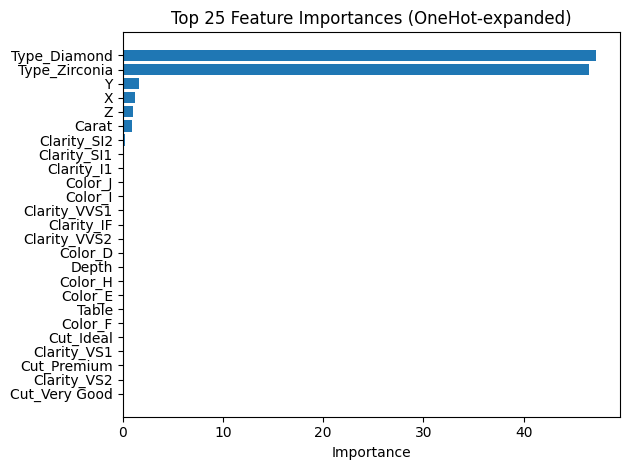

In [ ]:
importances = model.get_feature_importance()
imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
imp_df = imp_df.sort_values("importance", ascending=False)

top_n = 25
plt.figure()
plt.barh(imp_df["feature"].head(top_n)[::-1], imp_df["importance"].head(top_n)[::-1])
plt.title(f"Top {top_n} Feature Importances (OneHot-expanded)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

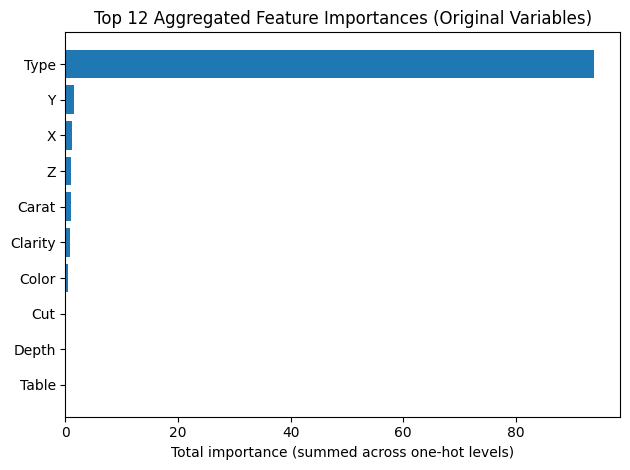

  base_feature  importance
6         Type   93.789247
8            Y    1.613574
7            X    1.254163
9            Z    0.990149
0        Carat    0.963766
1      Clarity    0.827120
2        Color    0.414010
3          Cut    0.061872
4        Depth    0.053526
5        Table    0.032575


In [ ]:
def base_feature_name(feat: str):
    # Common patterns: "cat__Color_H", "num__Carat"
    # Convert to base: "Color", "Carat"
    s = str(feat)
    if "__" in s:
        s = s.split("__", 1)[1]
    # OneHotEncoder uses "Color_H" -> base "Color"
    if "_" in s:
        # This will treat "X" and "Y" correctly if they have no underscore
        base = s.split("_", 1)[0]
        return base
    return s

imp_df["base_feature"] = imp_df["feature"].map(base_feature_name)
agg = imp_df.groupby("base_feature", as_index=False)["importance"].sum().sort_values("importance", ascending=False)

top_n = 12
plt.figure()
plt.barh(agg["base_feature"].head(top_n)[::-1], agg["importance"].head(top_n)[::-1])
plt.title(f"Top {top_n} Aggregated Feature Importances (Original Variables)")
plt.xlabel("Total importance (summed across one-hot levels)")
plt.tight_layout()
plt.show()

print(agg.head(15))

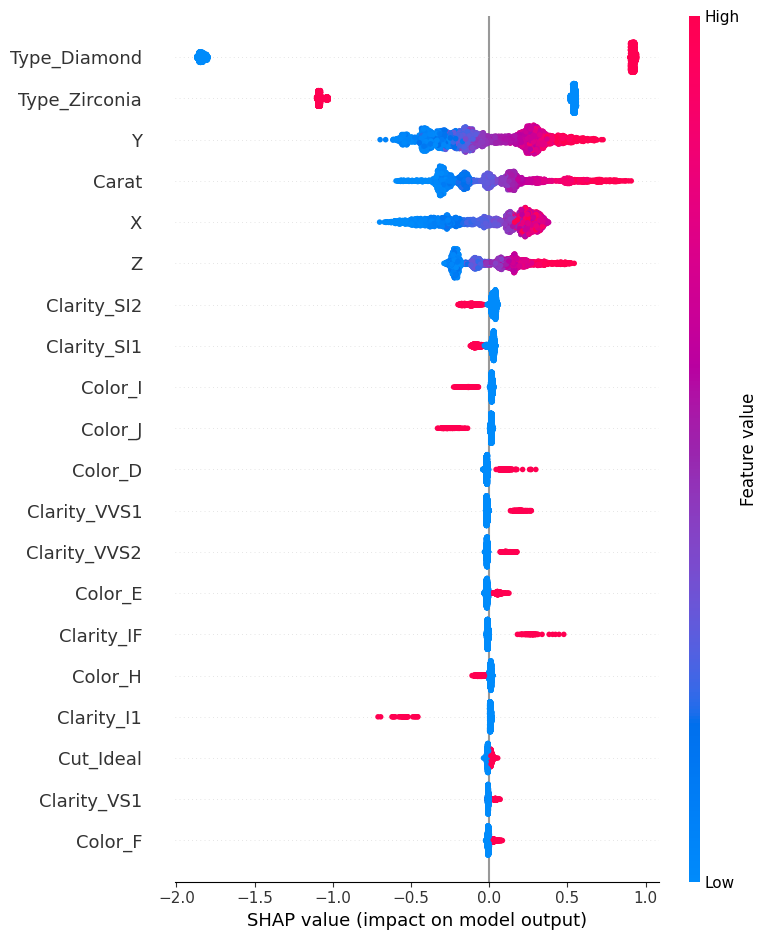

In [ ]:
import shap

# Sample for speed
sample_n = 3000
X_sample = X.sample(n=min(sample_n, len(X)), random_state=42)
Xt_sample = prep.transform(X_sample)

# SHAP explainer for tree models
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(Xt_sample)

# Summary plot (global importance + direction)
# NOTE: This uses matplotlib internally.
shap.summary_plot(shap_values, Xt_sample, feature_names=feature_names, show=True)

Top feature: Type_Diamond


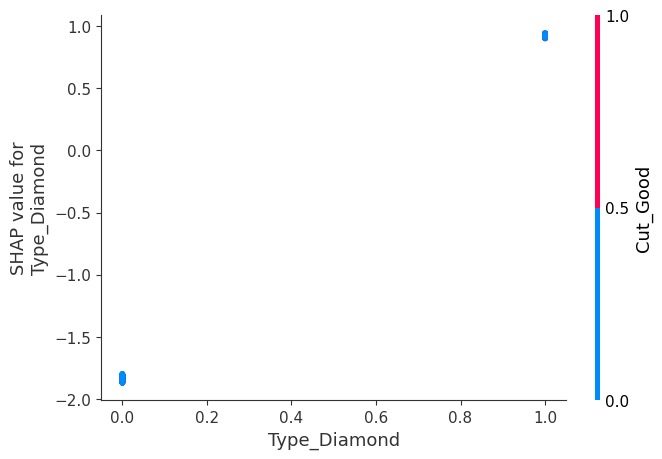

In [ ]:
top_feat = imp_df["feature"].iloc[0]
print("Top feature:", top_feat)

shap.dependence_plot(top_feat, shap_values, Xt_sample, feature_names=feature_names, show=True)

In [ ]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 8.1 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import joblib
import optuna

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error

from xgboost import XGBRegressor
from catboost import CatBoostRegressor


# ======================
# PATHS
# ======================
MODEL_PATH = "/content/drive/MyDrive/Diamond Dataset/Best_CatBoost_Bayesian_LogPrice.joblib"
TRAIN_PATH = "/content/drive/MyDrive/Diamond Dataset/Datasets/Train Dataset with Log Price.csv"   # change name if needed
TEST_PATH  = "/content/drive/MyDrive/Diamond Dataset/Datasets/Test Dataset with Log Price.csv"    # change name if needed
OUT_COMPARE_CSV = "/content/drive/MyDrive/Diamond Dataset/Datasets/compare_full_vs_reduced_tuned.csv"

TARGET = "LogPrice"
DROP_COLS = ["Price", "LogPrice"]

RANDOM_STATE = 42
VAL_SIZE = 0.2
N_TRIALS = 40
EARLY_STOP = 50


# ======================
# IMPORTANT FEATURES (your list)
# ======================
important_features = ["Type", "Y", "X", "Z", "Carat", "Clarity", "Color"]
# Optional include Cut if you want:
# important_features = ["Type", "Y", "X", "Z", "Carat", "Clarity", "Color", "Cut"]


# ======================
# METRICS
# ======================
def mape_log(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.clip(np.abs(y_true), eps, None)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100.0)

def metrics(y_true, y_pred):
    return {
        "R2": float(r2_score(y_true, y_pred)),
        "MSE": float(mean_squared_error(y_true, y_pred)),
        "MAPE(%)": float(mape_log(y_true, y_pred)),
    }

def eval_pipe(pipe, X_train, y_train, X_test, y_test):
    pipe.fit(X_train, y_train)
    pred_tr = pipe.predict(X_train)
    pred_te = pipe.predict(X_test)
    tr = metrics(y_train, pred_tr)
    te = metrics(y_test, pred_te)
    return {
        "Train_R2": tr["R2"], "Train_MSE": tr["MSE"], "Train_MAPE(%)": tr["MAPE(%)"],
        "Test_R2": te["R2"],  "Test_MSE": te["MSE"],  "Test_MAPE(%)": te["MAPE(%)"],
    }


# ======================
# LOAD DATA
# ======================
train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

y_train_full = train_df[TARGET].astype(float)
y_test = test_df[TARGET].astype(float)

X_train_full = train_df.drop(columns=DROP_COLS, errors="ignore")
X_test_full  = test_df.drop(columns=DROP_COLS, errors="ignore")

# Reduced feature sets
X_train_red = X_train_full[important_features].copy()
X_test_red  = X_test_full[important_features].copy()


# ======================
# 1) Benchmark: SAVED FULL CatBoost pipeline
# ======================
full_pipe = joblib.load(MODEL_PATH)

pred_full_train = full_pipe.predict(X_train_full)
pred_full_test  = full_pipe.predict(X_test_full)

tr_full = metrics(y_train_full, pred_full_train)
te_full = metrics(y_test, pred_full_test)

results = [{
    "Model": "CatBoost (FULL saved)",
    "Setup": "Full (saved .joblib)",
    "Train_R2": tr_full["R2"], "Train_MSE": tr_full["MSE"], "Train_MAPE(%)": tr_full["MAPE(%)"],
    "Test_R2": te_full["R2"],  "Test_MSE": te_full["MSE"],  "Test_MAPE(%)": te_full["MAPE(%)"],
}]


# ======================
# Preprocess for reduced features (for XGB + Cat)
# ======================
def make_preprocess(X):
    cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    num_cols = [c for c in X.columns if c not in cat_cols]

    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer([
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ], remainder="drop")

# internal tuning split
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train_red, y_train_full, test_size=VAL_SIZE, random_state=RANDOM_STATE
)

prep_fit = make_preprocess(X_fit).fit(X_fit)
X_fit_t = prep_fit.transform(X_fit)
X_val_t = prep_fit.transform(X_val)

# for final training/eval
prep_full_red = make_preprocess(X_train_red).fit(X_train_red)
X_train_red_t = prep_full_red.transform(X_train_red)
X_test_red_t  = prep_full_red.transform(X_test_red)


# ======================
# 2) Bayesian tuning: XGBoost (reduced)
# ======================
def tune_xgb():
    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 500, 3000),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 12),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
            "gamma": trial.suggest_float("gamma", 0.0, 0.5),
            "objective": "reg:squarederror",
            "random_state": RANDOM_STATE,
            "n_jobs": -1,
        }
        model = XGBRegressor(**params)
        model.fit(
            X_fit_t, y_fit,
            eval_set=[(X_val_t, y_val)],
            verbose=False
            # early_stopping_rounds=EARLY_STOP # Removed due to TypeError in current XGBoost version
        )
        pred = model.predict(X_val_t)
        return mean_squared_error(y_val, pred)

    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
    return study.best_params

print("\n=== Tuning XGBoost on IMPORTANT FEATURES ===")
best_xgb = tune_xgb()
print("Best XGBoost params:", best_xgb)

xgb_tuned = XGBRegressor(**{**best_xgb, "objective":"reg:squarederror", "random_state":RANDOM_STATE, "n_jobs":-1})
xgb_tuned.fit(X_train_red_t, y_train_full)

pred_tr = xgb_tuned.predict(X_train_red_t)
pred_te = xgb_tuned.predict(X_test_red_t)
tr = metrics(y_train_full, pred_tr)
te = metrics(y_test, pred_te)

results.append({
    "Model": "XGBoost",
    "Setup": "Reduced (important) + Tuned(Bayesian)",
    "Train_R2": tr["R2"], "Train_MSE": tr["MSE"], "Train_MAPE(%)": tr["MAPE(%)"],
    "Test_R2": te["R2"],  "Test_MSE": te["MSE"],  "Test_MAPE(%)": te["MAPE(%)"],
})


# ======================
# 3) Bayesian tuning: CatBoost (reduced)
# ======================
def tune_cat():
    def objective(trial):
        params = {
            "iterations": trial.suggest_int("iterations", 800, 4000),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
            "depth": trial.suggest_int("depth", 5, 10),
            "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 15.0),
            "random_strength": trial.suggest_float("random_strength", 0.0, 2.0),
            "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 2.0),
            "loss_function": "RMSE",
            "random_seed": RANDOM_STATE,
            "verbose": 0,
        }
        model = CatBoostRegressor(**params)
        model.fit(
            X_fit_t, y_fit,
            eval_set=(X_val_t, y_val),
            use_best_model=True,
            verbose=False,
            early_stopping_rounds=EARLY_STOP
        )
        pred = model.predict(X_val_t)
        return mean_squared_error(y_val, pred)

    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
    return study.best_params

print("\n=== Tuning CatBoost on IMPORTANT FEATURES ===")
best_cat = tune_cat()
print("Best CatBoost params:", best_cat)

cat_tuned = CatBoostRegressor(**{**best_cat, "loss_function":"RMSE", "random_seed":RANDOM_STATE, "verbose":0})
cat_tuned.fit(X_train_red_t, y_train_full)

pred_tr = cat_tuned.predict(X_train_red_t)
pred_te = cat_tuned.predict(X_test_red_t)
tr = metrics(y_train_full, pred_tr)
te = metrics(y_test, pred_te)

results.append({
    "Model": "CatBoost",
    "Setup": "Reduced (important) + Tuned(Bayesian)",
    "Train_R2": tr["R2"], "Train_MSE": tr["MSE"], "Train_MAPE(%)": tr["MAPE(%)"],
    "Test_R2": te["R2"],  "Test_MSE": te["MSE"],  "Test_MAPE(%)": te["MAPE(%)"],
})


# ======================
# FINAL COMPARISON
# ======================
res_df = pd.DataFrame(results).sort_values("Test_MSE")
print("\n===== COMPARISON: Saved Full CatBoost vs New Reduced Tuned Models ====")
print(res_df.to_string(index=False))

# Save to Drive
res_df.to_csv(OUT_COMPARE_CSV, index=False)
print("\nSaved comparison CSV:", OUT_COMPARE_CSV)

print("\nBest XGBoost params:", best_xgb)
print("Best CatBoost params:", best_cat)

[I 2026-02-26 05:52:23,492] A new study created in memory with name: no-name-d398afa6-402a-4c08-bf0e-84fd51a38b24



=== Tuning XGBoost on IMPORTANT FEATURES ===


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-02-26 05:52:43,126] Trial 0 finished with value: 0.011081057217868838 and parameters: {'n_estimators': 1436, 'learning_rate': 0.13125830316209655, 'max_depth': 8, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2, 'reg_lambda': 0.13066739238053282, 'gamma': 0.4330880728874676}. Best is trial 0 with value: 0.011081057217868838.
[I 2026-02-26 05:52:53,994] Trial 1 finished with value: 0.010326963454837928 and parameters: {'n_estimators': 2003, 'learning_rate': 0.06803900745073706, 'max_depth': 3, 'subsample': 0.9879639408647978, 'colsample_bytree': 0.9329770563201687, 'min_child_weight': 3, 'reg_lambda': 0.23102018878452935, 'gamma': 0.09170225492671691}. Best is trial 1 with value: 0.010326963454837928.
[I 2026-02-26 05:52:58,664] Trial 2 finished with value: 0.009947396429770942 and parameters: {'n_estimators': 1260, 'learning_rate': 0.04141536110538596, 'max_depth': 6, 'subsample': 0.7164916560792167, 'colsample_bytree': 0.844741157

[I 2026-02-26 06:01:18,042] A new study created in memory with name: no-name-5dcf34de-9b1c-4919-a41a-c5bd795c3d26



=== Tuning CatBoost on IMPORTANT FEATURES ===


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-02-26 06:01:50,442] Trial 0 finished with value: 0.006871615126153767 and parameters: {'iterations': 1998, 'learning_rate': 0.13125830316209655, 'depth': 9, 'l2_leaf_reg': 9.381218778758512, 'random_strength': 0.31203728088487304, 'bagging_temperature': 0.3119890406724053}. Best is trial 0 with value: 0.006871615126153767.
[I 2026-02-26 06:01:59,910] Trial 1 finished with value: 0.007768954673379946 and parameters: {'iterations': 985, 'learning_rate': 0.10440040750544663, 'depth': 8, 'l2_leaf_reg': 10.913016089144637, 'random_strength': 0.041168988591604894, 'bagging_temperature': 1.9398197043239886}. Best is trial 0 with value: 0.006871615126153767.
[I 2026-02-26 06:02:26,506] Trial 2 finished with value: 0.007963824544562393 and parameters: {'iterations': 3464, 'learning_rate': 0.01777174904859463, 'depth': 6, 'l2_leaf_reg': 3.5676631379480734, 'random_strength': 0.6084844859190754, 'bagging_temperature': 1.0495128632644757}. Best is trial 0 with value: 0.006871615126153767.


In [ ]:
import json
import joblib
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from catboost import CatBoostRegressor
TRAIN_PATH = "/content/drive/MyDrive/Diamond Dataset/Datasets/Train Dataset with Log Price.csv"
# ------------------------
# PATHS (DO NOT overwrite old)
# ------------------------
OLD_FULL_MODEL = "/content/drive/MyDrive/Diamond Dataset/Best_CatBoost_Bayesian_LogPrice.joblib"

# New output filenames (unique) - these are NEW files, old is untouched
FULL_COPY_JOBLIB = "/content/drive/MyDrive/Diamond Dataset/Datasets/DiamondIntel_CatBoost_FULL_COPY.joblib"
REDUCED_JOBLIB   = "/content/drive/MyDrive/Diamond Dataset/Datasets/DiamondIntel_CatBoost_REDUCED_Best.joblib"

# Optional: CatBoost native formats
FULL_COPY_CBM = "/content/drive/MyDrive/Diamond Dataset/Datasets/DiamondIntel_CatBoost_FULL_COPY.cbm"
REDUCED_CBM   = "/content/drive/MyDrive/Diamond Dataset/Datasets/DiamondIntel_CatBoost_REDUCED_Best.cbm"

META_JSON = "/content/drive/MyDrive/Diamond Dataset/Datasets/DiamondIntel_ModelMeta.json"

# Data for training reduced model
TARGET_COL = "LogPrice"
LEAK_COL = "Price"

# ------------------------
# 1) LOAD full model and SAVE AS COPY (no overwrite)
# ------------------------
full_pipe = joblib.load(OLD_FULL_MODEL)

joblib.dump(full_pipe, FULL_COPY_JOBLIB)
print("Saved FULL model copy (.joblib):", FULL_COPY_JOBLIB)

# save native model too (optional)
full_pipe.named_steps["model"].save_model(FULL_COPY_CBM)
print("Saved FULL model copy (.cbm):", FULL_COPY_CBM)

# ------------------------
# 2) TRAIN reduced model (important features only) + save
#    IMPORTANT: Drop Price & LogPrice from predictors (leakage + target)
# ------------------------
important_cols = ["Type", "X", "Y", "Z", "Carat", "Clarity", "Color"]  # add "Cut" if you want

df = pd.read_csv(TRAIN_PATH)

# Target
if TARGET_COL not in df.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found in {TRAIN_PATH}")
y = df[TARGET_COL].astype(float)

# Full predictors (drop leakage + target)
X_all = df.drop(columns=[LEAK_COL, TARGET_COL], errors="ignore")

# Reduced predictors (only important columns)
missing = [c for c in important_cols if c not in X_all.columns]
if missing:
    raise ValueError(f"These important columns are missing in predictors: {missing}")

X = X_all[important_cols].copy()

# detect types
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = [c for c in important_cols if c not in cat_cols]

# preprocess for reduced model
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocess = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
])

# Best REDUCED CatBoost params (from your message)
best_reduced_cat_params = {
    "iterations": 3638,
    "learning_rate": 0.08976994127916818,
    "depth": 10,
    "l2_leaf_reg": 4.827627866090003,
    "random_strength": 1.40414754906368,
    "bagging_temperature": 0.5543425728698019,
    "loss_function": "RMSE",
    "random_seed": 42,
    "verbose": 0
}

reduced_model = CatBoostRegressor(**best_reduced_cat_params)

reduced_pipe = Pipeline([
    ("prep", preprocess),
    ("model", reduced_model)
])

reduced_pipe.fit(X, y)

joblib.dump(reduced_pipe, REDUCED_JOBLIB)
print("Saved REDUCED model (.joblib):", REDUCED_JOBLIB)

# save native reduced model too (optional)
reduced_pipe.named_steps["model"].save_model(REDUCED_CBM)
print("Saved REDUCED model (.cbm):", REDUCED_CBM)

# ------------------------
# 3) Save meta (q90/q95) for website prediction interval
# ------------------------
meta = {
    "log_transform": "ln(price)",
    "target": TARGET_COL,
    "leakage_column_dropped": LEAK_COL,
    "dropped_from_predictors": [LEAK_COL, TARGET_COL],
    "full_model_original_joblib": OLD_FULL_MODEL,
    "full_model_copy_joblib": FULL_COPY_JOBLIB,
    "reduced_model_joblib": REDUCED_JOBLIB,
    "important_features_used_for_reduced": important_cols,
    "prediction_interval_q90_log": 0.104516,
    "prediction_interval_q95_log": 0.141486
}

with open(META_JSON, "w") as f:
    json.dump(meta, f, indent=2)

print("Saved metadata JSON:", META_JSON)

Saved FULL model copy (.joblib): /content/drive/MyDrive/Diamond Dataset/Datasets/DiamondIntel_CatBoost_FULL_COPY.joblib
Saved FULL model copy (.cbm): /content/drive/MyDrive/Diamond Dataset/Datasets/DiamondIntel_CatBoost_FULL_COPY.cbm
Saved REDUCED model (.joblib): /content/drive/MyDrive/Diamond Dataset/Datasets/DiamondIntel_CatBoost_REDUCED_Best.joblib
Saved REDUCED model (.cbm): /content/drive/MyDrive/Diamond Dataset/Datasets/DiamondIntel_CatBoost_REDUCED_Best.cbm
Saved metadata JSON: /content/drive/MyDrive/Diamond Dataset/Datasets/DiamondIntel_ModelMeta.json


In [ ]:
import json
import joblib
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from catboost import CatBoostRegressor


# =========================
# PATHS (EDIT if needed)
# =========================
OLD_FULL_MODEL = "/content/drive/MyDrive/Diamond Dataset/Best_CatBoost_Bayesian_LogPrice.joblib"   # only needed to compute PI for reduced model

OUT_DIR = "/content/drive/MyDrive/Diamond Dataset/Datasets"

# New model outputs (DO NOT overwrite old model)
FULL_COPY_JOBLIB = f"{OUT_DIR}/DiamondIntel_CatBoost_FULL_COPY.joblib"
REDUCED_JOBLIB   = f"{OUT_DIR}/DiamondIntel_CatBoost_REDUCED_Best.joblib"

# Optional native CatBoost outputs
FULL_COPY_CBM = f"{OUT_DIR}/DiamondIntel_CatBoost_FULL_COPY.cbm"
REDUCED_CBM   = f"{OUT_DIR}/DiamondIntel_CatBoost_REDUCED_Best.cbm"

# Metadata output
META_JSON = f"{OUT_DIR}/DiamondIntel_ModelMeta.json"

TARGET_COL = "LogPrice"
LEAK_COL = "Price"

TRAIN_CSV = f"{OUT_DIR}/Train Dataset with Log Price.csv"
TEST_CSV = f"{OUT_DIR}/Test Dataset with Log Price.csv"

# =========================
# HELPERS
# =========================
def prediction_band_from_residuals(y_true, y_pred, coverage=0.95):
    """Symmetric PI half-width q: P(|y - yhat| <= q)"""
    resid = np.asarray(y_true) - np.asarray(y_pred)
    return float(np.quantile(np.abs(resid), coverage))


def compute_pi_constants(pipe, X_df, y_series):
    """Compute q90/q95 on LogPrice using given pipe and test data."""
    pred = pipe.predict(X_df)
    q90 = prediction_band_from_residuals(y_series, pred, 0.90)
    q95 = prediction_band_from_residuals(y_series, pred, 0.95)
    cov90 = float(np.mean((y_series.to_numpy() >= (pred - q90)) & (y_series.to_numpy() <= (pred + q90))))
    cov95 = float(np.mean((y_series.to_numpy() >= (pred - q95)) & (y_series.to_numpy() <= (pred + q95))))
    return {"q90_log": q90, "q95_log": q95, "empirical_cov90": cov90, "empirical_cov95": cov95}


def safe_drop(df, cols):
    return df.drop(columns=[c for c in cols if c in df.columns], errors="ignore")


# =========================
# 1) LOAD FULL MODEL + SAVE COPY
# =========================
full_pipe = joblib.load(OLD_FULL_MODEL)

joblib.dump(full_pipe, FULL_COPY_JOBLIB)
print("Saved FULL model copy (.joblib):", FULL_COPY_JOBLIB)

# Optional: save native model too
full_pipe.named_steps["model"].save_model(FULL_COPY_CBM)
print("Saved FULL model copy (.cbm):", FULL_COPY_CBM)


# =========================
# 2) TRAIN REDUCED MODEL (IMPORTANT FEATURES) + SAVE
# =========================
important_cols = ["Type", "X", "Y", "Z", "Carat", "Clarity", "Color"]  # add "Cut" if you want

df_train = pd.read_csv(TRAIN_CSV)

# Target
y_train = df_train[TARGET_COL].astype(float)

# Predictors: drop leakage + target
X_train_all = safe_drop(df_train, [LEAK_COL, TARGET_COL])

# Reduced X
missing = [c for c in important_cols if c not in X_train_all.columns]
if missing:
    raise ValueError(f"Missing important columns in train predictors: {missing}")
X_train_reduced = X_train_all[important_cols].copy()

# Detect cat/num
cat_cols = X_train_reduced.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = [c for c in important_cols if c not in cat_cols]

# Preprocess
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_reduced = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
])

# Best reduced CatBoost params (your tuned values)
best_reduced_cat_params = {
    "iterations": 3638,
    "learning_rate": 0.08976994127916818,
    "depth": 10,
    "l2_leaf_reg": 4.827627866090003,
    "random_strength": 1.40414754906368,
    "bagging_temperature": 0.5543425728698019,
    "loss_function": "RMSE",
    "random_seed": 42,
    "verbose": 0
}

reduced_pipe = Pipeline([
    ("prep", preprocess_reduced),
    ("model", CatBoostRegressor(**best_reduced_cat_params))
])

reduced_pipe.fit(X_train_reduced, y_train)

joblib.dump(reduced_pipe, REDUCED_JOBLIB)
print("Saved REDUCED model (.joblib):", REDUCED_JOBLIB)

# Optional: save native model too
reduced_pipe.named_steps["model"].save_model(REDUCED_CBM)
print("Saved REDUCED model (.cbm):", REDUCED_CBM)


# =========================
# 3) COMPUTE PI CONSTANTS (q90/q95) FOR BOTH MODELS
#    - FULL: uses ALL predictors (except Price/LogPrice)
#    - REDUCED: uses ONLY important_cols
# =========================
df_test = pd.read_csv(TEST_CSV)

y_test = df_test[TARGET_COL].astype(float)

X_test_all = safe_drop(df_test, [LEAK_COL, TARGET_COL])

# FULL PI on test
full_pi = compute_pi_constants(full_pipe, X_test_all, y_test)

# REDUCED PI on test
missing_test = [c for c in important_cols if c not in X_test_all.columns]
if missing_test:
    raise ValueError(f"Missing important columns in test predictors: {missing_test}")

X_test_reduced = X_test_all[important_cols].copy()
reduced_pi = compute_pi_constants(reduced_pipe, X_test_reduced, y_test)


# =========================
# 4) SAVE ONE META JSON WITH EVERYTHING YOU NEED FOR WEBSITE
# =========================
meta = {
    "project": "Diamond Intel",
    "target": TARGET_COL,
    "log_transform": "ln(price)",
    "drop_predictors": [LEAK_COL, TARGET_COL],

    "models": {
        "full": {
            "joblib_path": FULL_COPY_JOBLIB,
            "cbm_path": FULL_COPY_CBM,
            "expects_features": "ALL columns except Price and LogPrice",
            "prediction_interval": full_pi
        },
        "reduced": {
            "joblib_path": REDUCED_JOBLIB,
            "cbm_path": REDUCED_CBM,
            "expects_features": important_cols,
            "prediction_interval": reduced_pi,
            "important_cols": important_cols,
            "catboost_params": best_reduced_cat_params
        }
    },

    "notes": {
        "price_leakage": "Price is removed from predictors to prevent leakage.",
        "prediction_interval_method": "Symmetric residual-based PI on LogPrice using test residuals."
    }
}

with open(META_JSON, "w") as f:
    json.dump(meta, f, indent=2)

print("\nSaved Meta JSON:", META_JSON)
print("\nFULL PI:", full_pi)
print("REDUCED PI:", reduced_pi)

Saved FULL model copy (.joblib): /content/drive/MyDrive/Diamond Dataset/Datasets/DiamondIntel_CatBoost_FULL_COPY.joblib
Saved FULL model copy (.cbm): /content/drive/MyDrive/Diamond Dataset/Datasets/DiamondIntel_CatBoost_FULL_COPY.cbm
Saved REDUCED model (.joblib): /content/drive/MyDrive/Diamond Dataset/Datasets/DiamondIntel_CatBoost_REDUCED_Best.joblib
Saved REDUCED model (.cbm): /content/drive/MyDrive/Diamond Dataset/Datasets/DiamondIntel_CatBoost_REDUCED_Best.cbm

Saved Meta JSON: /content/drive/MyDrive/Diamond Dataset/Datasets/DiamondIntel_ModelMeta.json

FULL PI: {'q90_log': 0.10451625873206337, 'q95_log': 0.1414864897466198, 'empirical_cov90': 0.9, 'empirical_cov95': 0.95}
REDUCED PI: {'q90_log': 0.11965257880065706, 'q95_log': 0.15735239241968643, 'empirical_cov90': 0.9, 'empirical_cov95': 0.95}
